In [3]:
%pip install nba_api pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
from nba_api.stats.static import players, teams

all_players = players.get_players()
print(len(all_players), "players found")
players.find_players_by_full_name("LeBron James")

5103 players found


[{'id': 2544,
  'full_name': 'LeBron James',
  'first_name': 'LeBron',
  'last_name': 'James',
  'is_active': True}]

In [6]:
from nba_api.stats.endpoints import playercareerstats

lebron_id = 2544
career = playercareerstats.PlayerCareerStats(player_id=lebron_id)
df = career.get_data_frames()[0]
df

,PLAYER_ID,SEASON_ID,LEAGUE_ID,TEAM_ID,TEAM_ABBREVIATION,PLAYER_AGE,GP,GS,MIN,FGM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
0,2544,2003-04,00,1610612739,CLE,19.0,79,79,3120,622,...,0.754,99,333,432,465,130,58,273,149,1654
1,2544,2004-05,00,1610612739,CLE,20.0,80,80,3388,795,...,0.750,111,477,588,577,177,52,262,146,2175
2,2544,2005-06,00,1610612739,CLE,21.0,79,79,3361,875,...,0.738,75,481,556,521,123,66,260,181,2478
3,2544,2006-07,00,1610612739,CLE,22.0,78,78,3190,772,...,0.698,83,443,526,470,125,55,250,171,2132
4,2544,2007-08,00,1610612739,CLE,23.0,75,74,3027,794,...,0.712,133,459,592,539,138,81,255,165,2250
5,2544,2008-09,00,1610612739,CLE,24.0,81,81,3054,789,...,0.780,106,507,613,587,137,93,241,139,2304
6,2544,2009-10,00,1610612739,CLE,25.0,76,76,2966,768,...,0.767,71,483,554,651,125,77,261,119,2258
7,2544,2010-11,00,1610612748,MIA,26.0,79,79,3063,758,...,0.759,80,510,590,554,124,50,284,163,2111
8,2544,2011-12,00,1610612748,MIA,27.0,62,62,2326,621,...,0.771,94,398,492,387,115,50,213,96,1683
9,2544,2012-13,00,1610612748,MIA,28.0,76,76,2877,765,...,0.753,97,513,610,551,129,67,226,110,2036


In [7]:
def season_str(start_year):
    return f"{start_year}-{str(start_year + 1)[-2:]}"

season_str(2015)  # -> '2015-16'

'2015-16'

In [8]:
import time
import pandas as pd
from nba_api.stats.endpoints import leaguedashteamstats

league_3pt_trend = []

for start_year in range(2003, 2026):
    season = season_str(start_year)
    stats = leaguedashteamstats.LeagueDashTeamStats(
        season=season,
        season_type_all_star='Regular Season',
        per_mode_detailed='PerGame',      # per-game rate, not season totals
        measure_type_detailed_defense='Base'
    )
    df = stats.get_data_frames()[0]
    league_3pt_trend.append({
        'season': season,
        'avg_fg3a': df['FG3A'].mean(),   # league-average 3-pt attempts per game
        'avg_fg3m': df['FG3M'].mean(),
        'avg_fg3_pct': df['FG3_PCT'].mean()
    })
    time.sleep(0.6)  # stay polite to the rate limiter

league_df = pd.DataFrame(league_3pt_trend)
league_df

,season,avg_fg3a,avg_fg3m,avg_fg3_pct
0,2003-04,14.920690,5.182759,0.345552
1,2004-05,15.750000,5.600000,0.353167
2,2005-06,15.983333,5.726667,0.356867
3,2006-07,16.940000,6.070000,0.356800
4,2007-08,18.106667,6.563333,0.360233
5,2008-09,18.133333,6.653333,0.365433
6,2009-10,18.136667,6.440000,0.352767
7,2010-11,18.010000,6.463333,0.356267
8,2011-12,18.386667,6.406667,0.347233
9,2012-13,19.966667,7.163333,0.357567


In [9]:
from nba_api.stats.endpoints import playercareerstats

curry_id = 201939
curry_career = playercareerstats.PlayerCareerStats(player_id=curry_id)
curry_df = curry_career.get_data_frames()[0][['SEASON_ID', 'FG3A', 'FG3M', 'FG3_PCT']]
curry_df

,SEASON_ID,FG3A,FG3M,FG3_PCT
0,2009-10,380,166,0.437
1,2010-11,342,151,0.442
2,2011-12,121,55,0.455
3,2012-13,600,272,0.453
4,2013-14,615,261,0.424
5,2014-15,646,286,0.443
6,2015-16,886,402,0.454
7,2016-17,789,324,0.411
8,2017-18,501,212,0.423
9,2018-19,810,354,0.437


Matplotlib is building the font cache; this may take a moment.


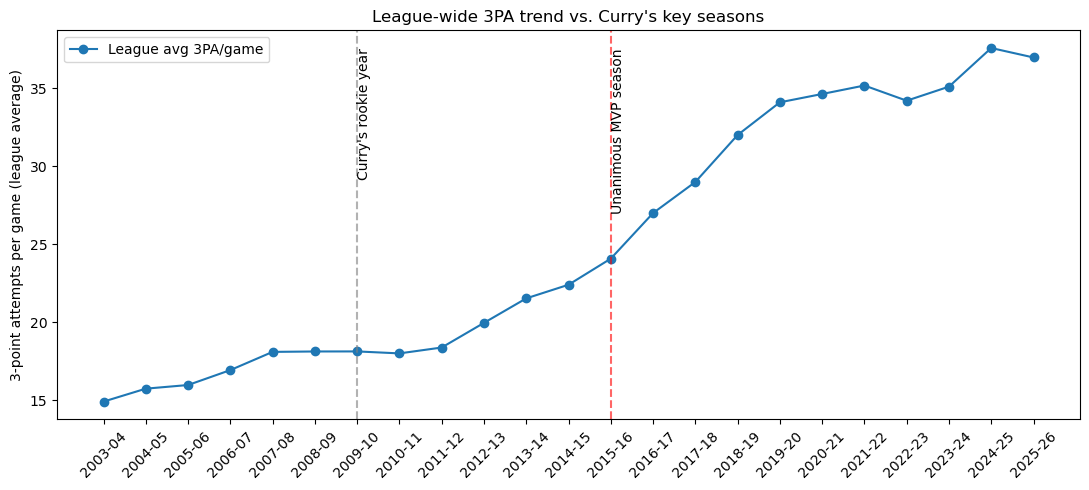

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(league_df['season'], league_df['avg_fg3a'], marker='o', label='League avg 3PA/game')

# mark Curry's rookie year and his unanimous-MVP season
ax.axvline('2009-10', color='gray', linestyle='--', alpha=0.6)
ax.text('2009-10', league_df['avg_fg3a'].max(), "Curry's rookie year", rotation=90, va='top')

ax.axvline('2015-16', color='red', linestyle='--', alpha=0.6)
ax.text('2015-16', league_df['avg_fg3a'].max(), "Unanimous MVP season", rotation=90, va='top')

plt.xticks(rotation=45)
ax.set_ylabel("3-point attempts per game (league average)")
ax.set_title("League-wide 3PA trend vs. Curry's key seasons")
ax.legend()
plt.tight_layout()
plt.show()